<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>K-Means Clustering - Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Understand what clustering is and how it differs from classification.</li>
<li>Understand what a cluster and a centroid are.</li>
<li>Visualize how K-Means works step by step.</li>
<li>Build intuition for why K-Means converges to a solution.</li>
</ol>
So far, every algorithm I've worked with (SVM, Naive Bayes) was 
<b>supervised</b> - the data had labels, and the model learned to 
predict them. K-Means is completely different - it's an 
<b>unsupervised</b> algorithm that finds patterns in data 
<i>without</i> any labels.
</div>

In [1]:
# Importing libraries needed for this notebook

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is Clustering?</b>
</h2>
<div style="font-family:'Times New Roman';">
<b>Clustering</b> is the task of grouping data points such that:
<ul>
<li>Points in the <b>same group</b> are similar to each other.</li>
<li>Points in <b>different groups</b> are as different as possible.</li>
</ul>
The key thing is - we don't tell the algorithm what the groups 
<i>are</i> or what they <i>mean</i>. We just give it data, and it 
figures out the grouping on its own based on how close points are 
to each other.
<br><br>
<b>Real-world examples:</b>
<ul>
<li>Grouping customers by purchasing behavior (for marketing)</li>
<li>Grouping news articles by topic</li>
<li>Compressing images by grouping similar colors together</li>
<li>Identifying different species based on physical measurements</li>
</ul>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Let's Look at Some Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's generate some synthetic data with 3 natural groups - but 
we'll plot it <b>without colors</b> first, just like an unsupervised 
algorithm would actually see it. No labels, just points.
</div>

Shape of data: (150, 2)


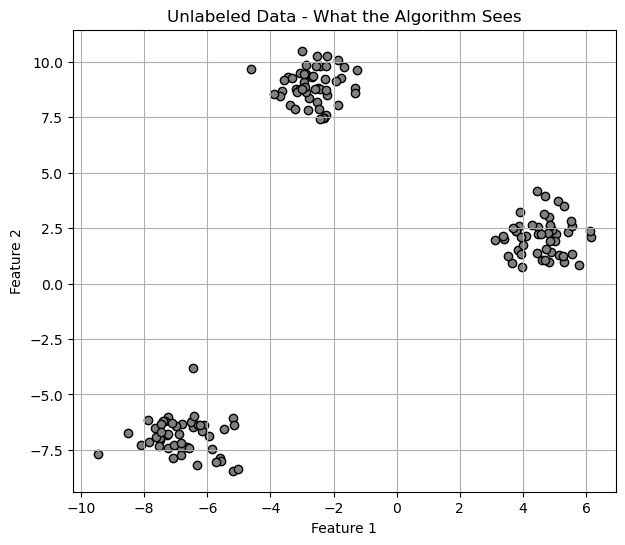

In [2]:
# Setting a seed for reproducibility
np.random.seed(42)

# Generating synthetic data with 3 natural groups (centers)
X, true_labels = make_blobs(n_samples=150, centers=3, cluster_std=0.8, random_state=42)

print("Shape of data:", X.shape)

# Plotting WITHOUT labels - this is what unsupervised learning sees
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k')
plt.title("Unlabeled Data - What the Algorithm Sees")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is a Cluster?</b>
</h2>
<div style="font-family:'Times New Roman';">
Even without labels, just by <i>looking</i> at the plot above, we 
can probably already see <b>3 distinct groups</b> of points. 
<br><br>
A <b>cluster</b> is exactly that a group of data points that are 
close together (similar to each other) and relatively far from 
points in other groups.
<br><br>
Let's now reveal the truu grouping (which we know coz we 
generated this data ourselves) just to confirm what our eyes 
already told us.
</div>

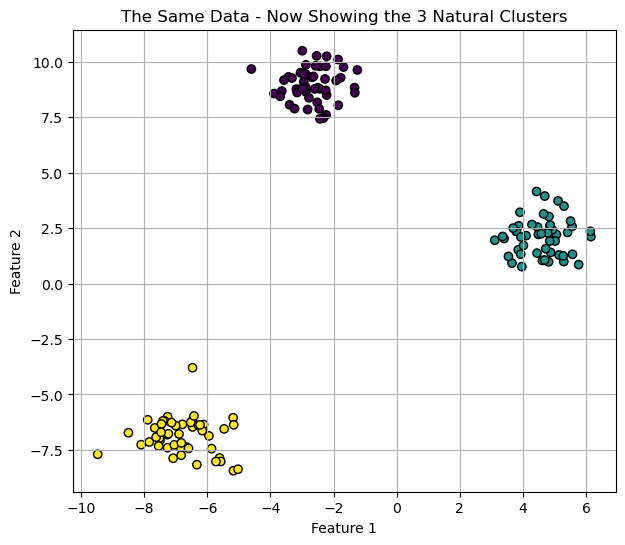

In [3]:
# Plotting the same data, but now colored by their true group
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', edgecolors='k')

plt.title("The Same Data - Now Showing the 3 Natural Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is a Centroid?</b>
</h2>
<div style="font-family:'Times New Roman';">
A <b>centroid</b> is simply the <b>"center point"</b> of a cluster - 
calculated as the <b>average position</b> of all points belonging 
to that cluster.
<br><br>
If a cluster has points at (1,1), (2,2), and (3,3), the centroid 
would be at:
<br>
((1+2+3)/3, (1+2+3)/3) = (2, 2)
<br><br>
K-Means is named after this idea - it tries to find <b>K centroids</b> 
(where K is a number we choose) such that every point is assigned 
to its <b>nearest centroid</b>, and the centroids represent the 
"center" of each group.
<br><br>
Let's calculate and visualize the centroids for our 3 true clusters.
</div>

Centroids (center of each cluster):
[[-2.66301205  8.9251602 ]
 [ 4.59523718  2.10914946]
 [-6.77912214 -6.88758091]]


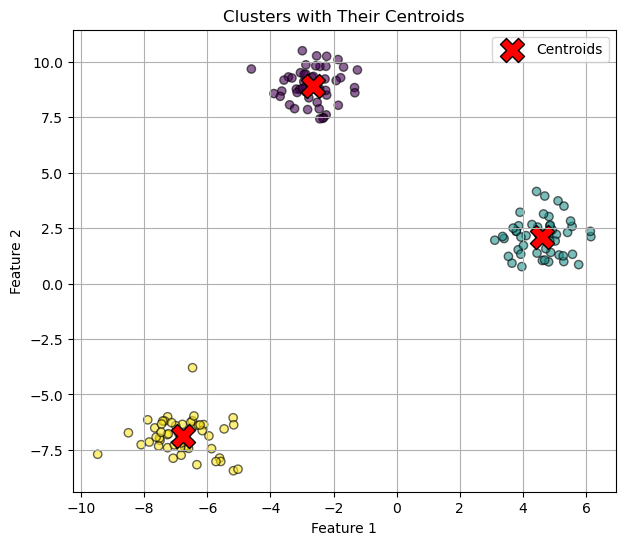

In [4]:
# Calculating the centroid of each true cluster
centroids = []
for cluster_id in np.unique(true_labels):
    cluster_points = X[true_labels == cluster_id]
    centroid = cluster_points.mean(axis=0)  # average of all points in this cluster
    centroids.append(centroid)

centroids = np.array(centroids)
print("Centroids (center of each cluster):")
print(centroids)

# Plotting clusters along with their centroids
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', edgecolors='k', alpha=0.6)

# Plotting centroids as large red X markers
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', marker='X', s=300, label='Centroids', edgecolors='black')

plt.title("Clusters with Their Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>How Does K-Means Work?</b>
</h2>
<div style="font-family:'Times New Roman';">
Here's the catch - in real problems, we <b>don't know</b> the true 
clusters or centroids in advance (that's the whole point of 
unsupervised learning!). So how does K-Means find them?
<br><br>
K-Means works through a simple, repeating 2-step process:
<br><br>
<b>Step 0 - Initialize:</b> Randomly place K centroids somewhere 
in the data.
<br><br>
<b>Step 1 - Assign:</b> Assign every data point to its 
<b>nearest centroid</b>. This forms K temporary clusters.
<br><br>
<b>Step 2 - Update:</b> Move each centroid to the 
<b>average position</b> of all points assigned to it.
<br><br>
<b>Repeat</b> Steps 1 and 2 until the centroids stop moving 
(or move by a very tiny amount) - this is called 
<b>convergence</b>.
<br><br>
Let's visualize this process step by step on our data, pretending 
we don't know the true clusters.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 0: Randomly Initialize Centroids</b>
</h2>
<div style="font-family:'Times New Roman';">
We choose <b>K = 3</b> (since we want 3 groups), and randomly pick 
3 points from our data to act as the initial centroids. 
<br><br>
Notice these starting points are <b>completely random</b> and 
probably don't represent the "true" centers at all yet.
</div>

Randomly chosen initial centroids:
[[ 3.8601335   2.60283737]
 [-1.91842436  9.15138075]
 [-2.82288415  7.84347417]]


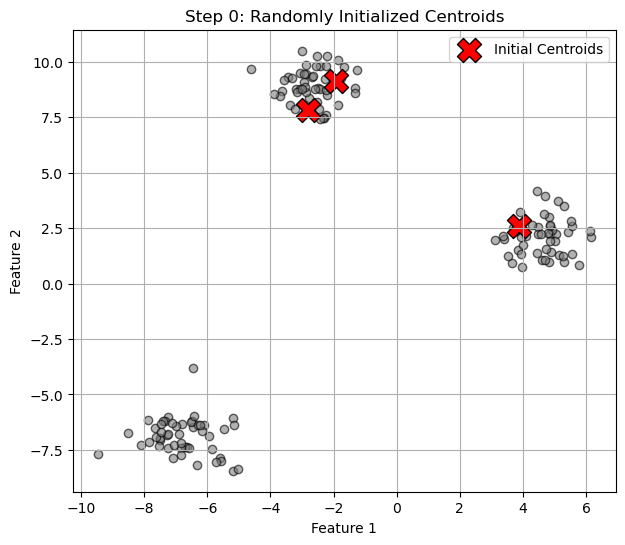

In [5]:
# Setting K (number of clusters)
K = 3

# Randomly selecting K points from the data to be initial centroids
np.random.seed(1)
random_indices = np.random.choice(len(X), K, replace=False)
current_centroids = X[random_indices]

print("Randomly chosen initial centroids:")
print(current_centroids)

# Plotting data (all gray, since no assignments yet) with initial centroids
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k', alpha=0.6)
plt.scatter(current_centroids[:, 0], current_centroids[:, 1],
            c='red', marker='X', s=300, label='Initial Centroids', edgecolors='black')

plt.title("Step 0: Randomly Initialized Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 1: Assign Each Point to Its Nearest Centroid</b>
</h2>
<div style="font-family:'Times New Roman';">
For every data point, we calculate its <b>distance</b> to each of 
the K centroids, and assign it to the <b>closest</b> one. 
<br><br>
This gives us our first (rough) clustering - but since the 
centroids started at random positions, this assignment probably 
isn't very good yet.
</div>

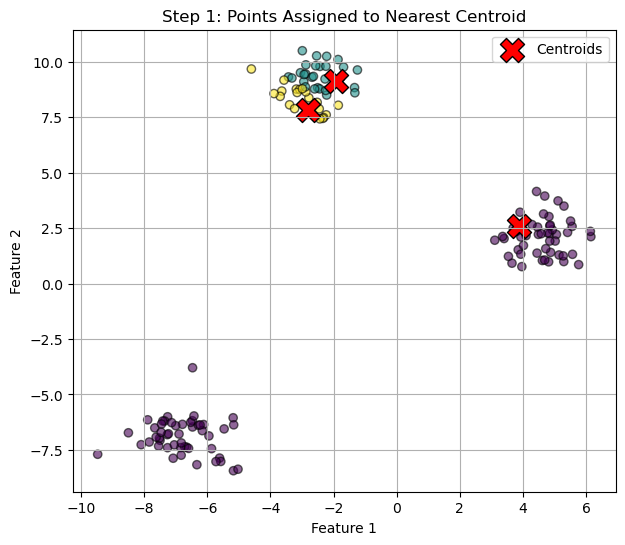

In [6]:
def assign_clusters(X, centroids):
    # Calculating distance from each point to each centroid
    # X has shape (n_samples, 2), centroids has shape (K, 2)
    # We use broadcasting to compute all distances at once

    distances = np.zeros((len(X), len(centroids)))

    for i, centroid in enumerate(centroids):
        # Euclidean distance from every point to this centroid
        distances[:, i] = np.sqrt(((X - centroid) ** 2).sum(axis=1))

    # For each point, picking the index of the closest centroid
    return np.argmin(distances, axis=1)


# Assigning clusters based on the initial random centroids
labels = assign_clusters(X, current_centroids)

# Plotting the data colored by their CURRENT (rough) cluster assignment
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.6)
plt.scatter(current_centroids[:, 0], current_centroids[:, 1],
            c='red', marker='X', s=300, label='Centroids', edgecolors='black')

plt.title("Step 1: Points Assigned to Nearest Centroid")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 2: Move Centroids to the Average of Their Points</b>
</h2>
<div style="font-family:'Times New Roman';">
Now that every point belongs to one of the 3 groups, we recalculate 
each centroid's position as the <b>average (mean)</b> of all points 
currently assigned to it.
<br><br>
The centroids will <b>move</b> towards the "true center" of their 
assigned points.
</div>

Old centroids:
[[ 3.8601335   2.60283737]
 [-1.91842436  9.15138075]
 [-2.82288415  7.84347417]]

New centroids (after update):
[[-1.09194248 -2.38921573]
 [-2.41668559  9.37872372]
 [-3.00317717  8.29881058]]


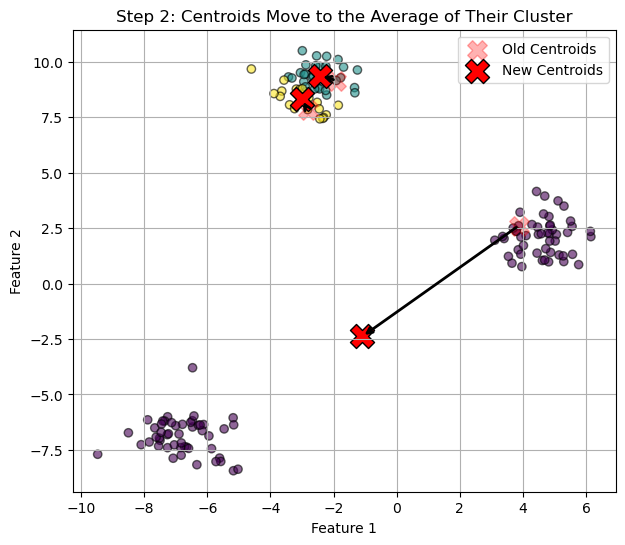

In [7]:
def update_centroids(X, labels, K):
    new_centroids = np.zeros((K, X.shape[1]))

    for k in range(K):
        # Getting all points currently assigned to cluster k
        points_in_cluster = X[labels == k]

        # New centroid = average position of these points
        new_centroids[k] = points_in_cluster.mean(axis=0)

    return new_centroids


# Updating centroids based on current assignments
new_centroids = update_centroids(X, labels, K)

print("Old centroids:")
print(current_centroids)
print("\nNew centroids (after update):")
print(new_centroids)

# Plotting old vs new centroid positions
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.6)

# Old centroids (faded)
plt.scatter(current_centroids[:, 0], current_centroids[:, 1],
            c='red', marker='X', s=200, alpha=0.3, label='Old Centroids')

# New centroids
plt.scatter(new_centroids[:, 0], new_centroids[:, 1],
            c='red', marker='X', s=300, label='New Centroids', edgecolors='black')

# Drawing arrows showing how centroids moved
for old, new in zip(current_centroids, new_centroids):
    plt.annotate('', xy=new, xytext=old,
                  arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.title("Step 2: Centroids Move to the Average of Their Cluster")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Repeating: Assign -> Update -> Assign -> Update...</b>
</h2>
<div style="font-family:'Times New Roman';">
We just did <b>one round</b> of assign-and-update. But one round 
usually isn't enough - the centroids moved, so the 
<b>nearest centroid for each point might have changed too</b>!
<br><br>
So we repeat the process:
<ol>
<li>Re-assign every point to its (possibly new) nearest centroid.</li>
<li>Re-calculate centroids based on these new assignments.</li>
</ol>
We keep repeating this until the centroids barely move anymore - 
this means the algorithm has <b>converged</b>.
<br><br>
Let's run several rounds and visualize how the centroids and 
clusters evolve.
</div>

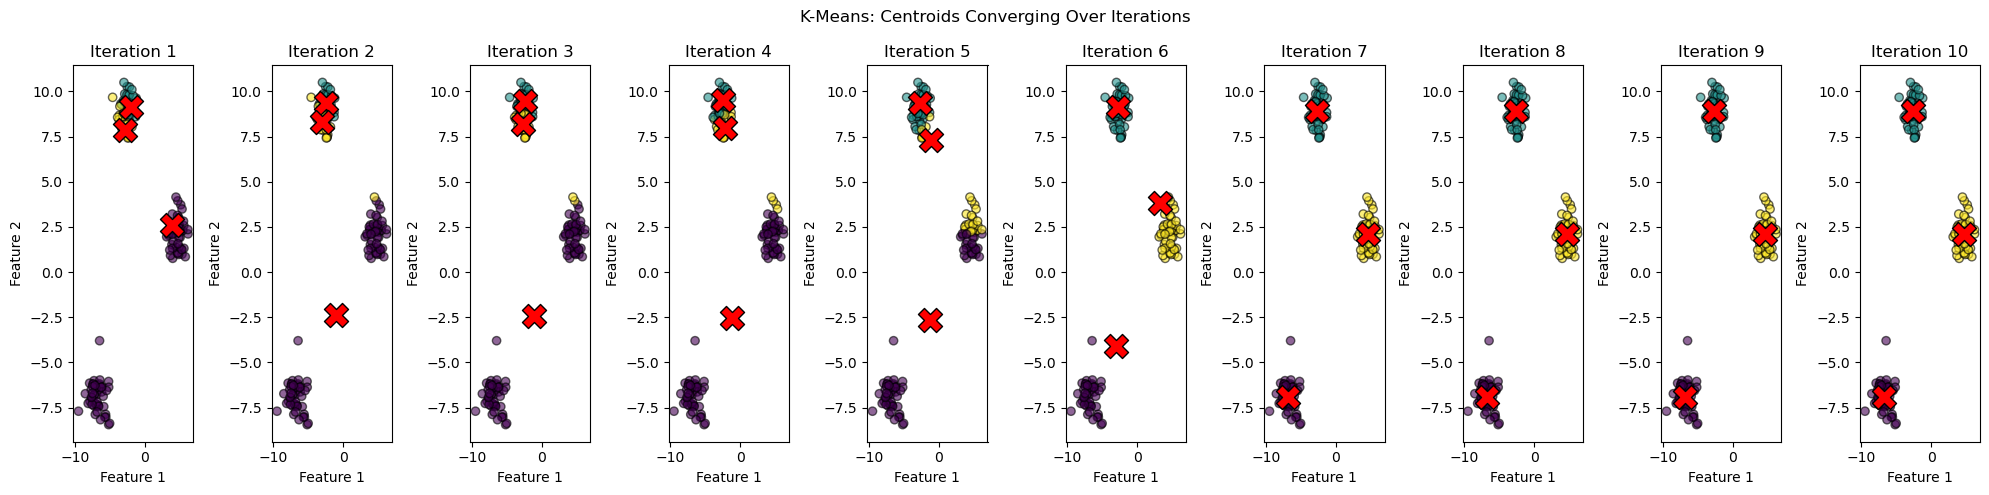

Final centroids after 10 iterations:
[[-6.77912214 -6.88758091]
 [-2.66301205  8.9251602 ]
 [ 4.59523718  2.10914946]]


In [10]:
# Resetting to the same initial centroids for a clean run
current_centroids = X[random_indices].copy()

n_iterations = 10 # number of rounds to visualize

fig, axes = plt.subplots(1, n_iterations, figsize=(20, 5))

for i in range(n_iterations):
    # Step 1: Assign points to nearest centroid
    labels = assign_clusters(X, current_centroids)

    # Plotting the current state (before updating centroids)
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.6)
    axes[i].scatter(current_centroids[:, 0], current_centroids[:, 1],
                    c='red', marker='X', s=300, edgecolors='black')
    axes[i].set_title(f"Iteration {i+1}")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")

    # Step 2: Update centroids based on these assignments
    current_centroids = update_centroids(X, labels, K)

plt.suptitle("K-Means: Centroids Converging Over Iterations")
plt.tight_layout()
plt.show()

print("Final centroids after", n_iterations, "iterations:")
print(current_centroids)

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Convergence: When Do We Stop?</b>
</h2>
<div style="font-family:'Times New Roman';">
Looking at the plots above, notice how the clusters change a lot in 
the early iterations, but barely change in the later ones. This is 
<b>convergence</b> the centroids have settled into stable positions, 
and further iterations won't change much (if anything).
<br><br>
In practice, K-Means stops when either:
<ul>
<li>The centroids move less than some tiny threshold between 
iterations, OR</li>
<li>A maximum number of iterations is reached.</li>
</ul>
Notice also how our final result (after just a few iterations) 
looks very similar to the <b>true clusters</b> we revealed earlier  
even though the algorithm had no idea about the true labels!
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What if We Choose the Wrong K?</b>
</h2>
<div style="font-family:'Times New Roman';">
One important thing about K-Means: <b>we have to choose K ourselves</b> 
 the algorithm doesn't figure out the "right" number of clusters on 
its own.
<br><br>
What happens if we pick K=2 or K=5 instead of the "natural" K=3 for 
our data? Let's visualize both cases.
</div>

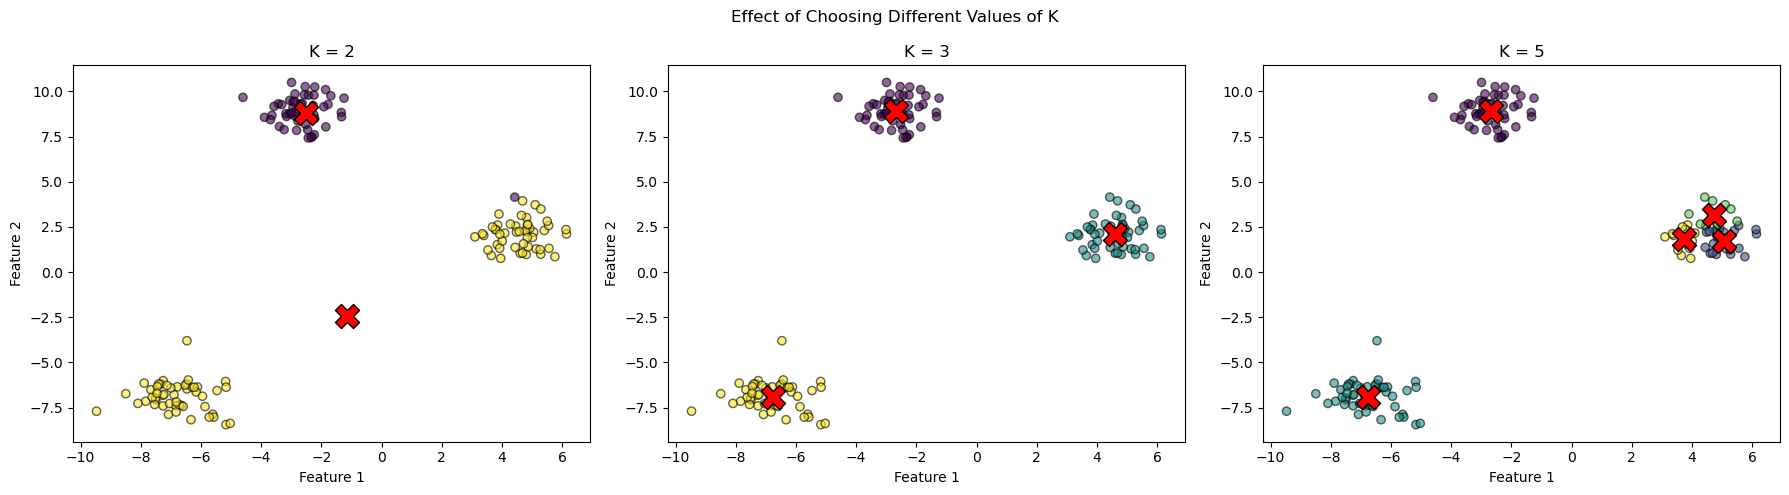

In [11]:
def run_kmeans_simple(X, K, n_iterations=10, seed=42):
    np.random.seed(seed)

    # Randomly initializing K centroids from the data points
    random_indices = np.random.choice(len(X), K, replace=False)
    centroids = X[random_indices].copy()

    for _ in range(n_iterations):
        labels = assign_clusters(X, centroids)
        centroids = update_centroids(X, labels, K)

    return labels, centroids


# Trying K = 2, 3, and 5
k_values = [2, 3, 5]

fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5))

for ax, k in zip(axes, k_values):
    labels, centroids = run_kmeans_simple(X, k)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.6)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='red', marker='X', s=300, edgecolors='black')
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Effect of Choosing Different Values of K")
plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li><b>Clustering:</b> grouping similar data points together, 
without using any labels - an <b>unsupervised</b> task.</li>
<li><b>Cluster:</b> a group of points that are close to each other 
and far from points in other groups.</li>
<li><b>Centroid:</b> the "center" of a cluster - the average 
position of all points in it.</li>
<li><b>K-Means Algorithm:</b>
<ol>
<li>Randomly initialize K centroids.</li>
<li><b>Assign:</b> each point goes to its nearest centroid.</li>
<li><b>Update:</b> move each centroid to the average of its 
assigned points.</li>
<li>Repeat until centroids stop moving (<b>convergence</b>).</li>
</ol>
</li>
<li><b>Choosing K:</b> the wrong K can split natural groups apart 
or merge separate groups together - choosing the right K is an 
important (and tricky) part of using K-Means, which we'll explore 
later (e.g., the Elbow Method).</li>
</ul>
Now that the intuition is clear, the next notebook will focus on 
<b>implementing K-Means completely from scratch</b> as a reusable 
class - similar to what I did for SVM and Naive Bayes.
</div>